In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
#Importing Training Dataset
train_data = pd.read_csv('Namma_Metro_stations(Bengaluru) - Train.csv')

In [3]:
#Maximum amount of columns to be printed
pd.set_option('display.max_columns', None)

In [4]:
#Displays First 5 rows of training dataset
train_data.head()

,Line,Date_Of_Journey,Source Station,Destination Station,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Purple Line,26/06/2023,Attiguppe,Whitefield(Kadugodi),KGWA -> MAGR -> KRAM,07:33:00,09:06:00,1h 31m,26,In-train announcements,70
1,Purple Line,21/03/2023,Baiyappanahalli,Whitefield(Kadugodi),BYP -> UWVL -> WHTM,18:00:00,18:46:46,46m,13,Open Web Girder(Benniganahalli),40
2,Green Line,13/01/2023,Banashankari,Nagasandra,RVR -> KGWA -> NGSA,19:49:00,21:13:12,1h 24m,21,In-train announcements,65
3,Purple Line,23/02/2023,Krantivira Sangolli Rayanna Railway Station,Challaghatta,MIRD -> MYRD -> RRRN,05:30:00,05:59:41,29m,12,Panchamukhi Ganesha Temple,38
4,Green Line,01/01/2023,Chickpete,Silk Institute,KGWA -> RVR -> BSNK,07:46:00,08:14:12,27m,14,In-train announcements,40


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Line                 101 non-null    object
 1   Date_Of_Journey      101 non-null    object
 2   Source Station       101 non-null    object
 3   Destination Station  101 non-null    object
 4   Route                101 non-null    object
 5   Dep_Time             101 non-null    object
 6   Arrival_Time         101 non-null    object
 7   Duration             101 non-null    object
 8   Total_Stops          101 non-null    int64 
 9   Additional_Info      101 non-null    object
 10  Price                101 non-null    int64 
dtypes: int64(2), object(9)
memory usage: 8.8+ KB


In [6]:
train_data["Duration"].value_counts()

39m        5
46m        5
52m        5
36m        5
1h 15m     4
33m        4
30m        3
1h         3
32m        3
38m        3
57m        3
1h 18m     2
24m        2
37m        2
50m        2
1h 11m     2
1h 24m     2
35m        2
29m        2
1h 7m      2
43m        2
47m        2
1h 20m     2
1h 13m     2
58m        1
40m        1
56m        1
34m        1
28m        1
18m        1
54m        1
1h 10m     1
55m        1
1hr 20m    1
49m        1
26m        1
1h 31m     1
1h 9 m     1
1h 19m     1
27m        1
1h 8m      1
1h 16m     1
45m        1
60m        1
1h  21m    1
42m        1
20m        1
25m        1
1h  24m    1
48m        1
1h 12m     1
41m        1
19m        1
12m        1
1hr 19m    1
1h 30m     1
Name: Duration, dtype: int64

In [7]:
train_data.dropna(inplace = True)

In [8]:
train_data.isnull().sum()

Line                   0
Date_Of_Journey        0
Source Station         0
Destination Station    0
Route                  0
Dep_Time               0
Arrival_Time           0
Duration               0
Total_Stops            0
Additional_Info        0
Price                  0
dtype: int64

# EDA


# Nominal Data

In [9]:
train_data["Journey_day"] = pd.to_datetime(train_data.Date_Of_Journey, format="%d/%m/%Y").dt.day

In [10]:
train_data["Journey_month"] = pd.to_datetime(train_data["Date_Of_Journey"], format = "%d/%m/%Y").dt.month

In [11]:
train_data["Dep_hour"] = pd.to_datetime(train_data["Dep_Time"]).dt.hour


train_data["Dep_min"] = pd.to_datetime(train_data["Dep_Time"]).dt.minute


train_data.drop(["Dep_Time"], axis = 1, inplace = True)

In [12]:
train_data.head()

,Line,Date_Of_Journey,Source Station,Destination Station,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,Purple Line,26/06/2023,Attiguppe,Whitefield(Kadugodi),KGWA -> MAGR -> KRAM,09:06:00,1h 31m,26,In-train announcements,70,26,6,7,33
1,Purple Line,21/03/2023,Baiyappanahalli,Whitefield(Kadugodi),BYP -> UWVL -> WHTM,18:46:46,46m,13,Open Web Girder(Benniganahalli),40,21,3,18,0
2,Green Line,13/01/2023,Banashankari,Nagasandra,RVR -> KGWA -> NGSA,21:13:12,1h 24m,21,In-train announcements,65,13,1,19,49
3,Purple Line,23/02/2023,Krantivira Sangolli Rayanna Railway Station,Challaghatta,MIRD -> MYRD -> RRRN,05:59:41,29m,12,Panchamukhi Ganesha Temple,38,23,2,5,30
4,Green Line,01/01/2023,Chickpete,Silk Institute,KGWA -> RVR -> BSNK,08:14:12,27m,14,In-train announcements,40,1,1,7,46


In [13]:
train_data.drop(["Date_Of_Journey"], axis = 1, inplace = True)

In [14]:
train_data["Arrival_hour"] = pd.to_datetime(train_data.Arrival_Time).dt.hour


train_data["Arrival_min"] = pd.to_datetime(train_data.Arrival_Time).dt.minute


train_data.drop(["Arrival_Time"], axis = 1, inplace = True)

In [15]:
train_data.head()

,Line,Source Station,Destination Station,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,Purple Line,Attiguppe,Whitefield(Kadugodi),KGWA -> MAGR -> KRAM,1h 31m,26,In-train announcements,70,26,6,7,33,9,6
1,Purple Line,Baiyappanahalli,Whitefield(Kadugodi),BYP -> UWVL -> WHTM,46m,13,Open Web Girder(Benniganahalli),40,21,3,18,0,18,46
2,Green Line,Banashankari,Nagasandra,RVR -> KGWA -> NGSA,1h 24m,21,In-train announcements,65,13,1,19,49,21,13
3,Purple Line,Krantivira Sangolli Rayanna Railway Station,Challaghatta,MIRD -> MYRD -> RRRN,29m,12,Panchamukhi Ganesha Temple,38,23,2,5,30,5,59
4,Green Line,Chickpete,Silk Institute,KGWA -> RVR -> BSNK,27m,14,In-train announcements,40,1,1,7,46,8,14


In [16]:
#Splitting duration columns into duration hours and minutes

duration = list(train_data["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:   
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   
        else:
            duration[i] = "0h " + duration[i]          

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))  

In [17]:
train_data.drop(["Duration"], axis = 1, inplace = True)

In [18]:
train_data.head()

,Line,Source Station,Destination Station,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,Purple Line,Attiguppe,Whitefield(Kadugodi),KGWA -> MAGR -> KRAM,26,In-train announcements,70,26,6,7,33,9,6
1,Purple Line,Baiyappanahalli,Whitefield(Kadugodi),BYP -> UWVL -> WHTM,13,Open Web Girder(Benniganahalli),40,21,3,18,0,18,46
2,Green Line,Banashankari,Nagasandra,RVR -> KGWA -> NGSA,21,In-train announcements,65,13,1,19,49,21,13
3,Purple Line,Krantivira Sangolli Rayanna Railway Station,Challaghatta,MIRD -> MYRD -> RRRN,12,Panchamukhi Ganesha Temple,38,23,2,5,30,5,59
4,Green Line,Chickpete,Silk Institute,KGWA -> RVR -> BSNK,14,In-train announcements,40,1,1,7,46,8,14


# Handling Categorical Data

In [19]:
#Encoding Categorical data into hashmap

def get_dummies_using_hashmap(train_data, columns):
    
     encoded_data = train_data.copy()
    
     for col in columns:
            value_code = {}
            for i, value in enumerate(train_data[col].unique()):
                value_code[value] = i
        
        
            for value in value_code:
                encoded_col = col + '_' + str(value)
                encoded_data[encoded_col] = train_data[col].map(value_code).eq(value_code[value]).astype(int)
        
        
            encoded_data.drop(col, axis=1, inplace=True)
    
     return encoded_data

In [20]:
#Counts the no. of values of each category in Line Column
train_data['Line'].value_counts()

Purple Line          41
Green Line           34
Interchange Lines    13
Blue Line             7
Yellow Line           3
Pink Line             3
Name: Line, dtype: int64

In [21]:
train_data['Source Station'].value_counts()

Indiranagar                           6
Whitefield (Kadugodi)                 3
Rashtreeya Vidyalaya Metro Station    3
Silk Institute                        3
Hopefarm Channasandra                 2
                                     ..
Lalbagh                               1
Kundalahalli                          1
Konanakunte Cross                     1
Kengeri Bus Terminal                  1
Kalyan Nagar                          1
Name: Source Station, Length: 81, dtype: int64

In [22]:
#Converting Line column into numerical values
data = pd.DataFrame({'Line': ['Purple Line', 'Green Line', 'Interchange Lines', 'Blue Line', 'Yellow Line','Pink Line']})

encoded_data = get_dummies_using_hashmap(data, ['Line'])
print(encoded_data)

   Line_Purple Line  Line_Green Line  Line_Interchange Lines  Line_Blue Line  \
0                 1                0                       0               0   
1                 0                1                       0               0   
2                 0                0                       1               0   
3                 0                0                       0               1   
4                 0                0                       0               0   
5                 0                0                       0               0   

   Line_Yellow Line  Line_Pink Line  
0                 0               0  
1                 0               0  
2                 0               0  
3                 0               0  
4                 1               0  
5                 0               1  


In [23]:
Line = train_data[["Line"]]

Line = pd.get_dummies(Line, drop_first= True)

Line.head()

,Line_Green Line,Line_Interchange Lines,Line_Pink Line,Line_Purple Line,Line_Yellow Line
0,0,0,0,1,0
1,0,0,0,1,0
2,1,0,0,0,0
3,0,0,0,1,0
4,1,0,0,0,0


In [24]:
train_data.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [25]:
train_data.head()

,Line,Source Station,Destination Station,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,Purple Line,Attiguppe,Whitefield(Kadugodi),26,70,26,6,7,33,9,6
1,Purple Line,Baiyappanahalli,Whitefield(Kadugodi),13,40,21,3,18,0,18,46
2,Green Line,Banashankari,Nagasandra,21,65,13,1,19,49,21,13
3,Purple Line,Krantivira Sangolli Rayanna Railway Station,Challaghatta,12,38,23,2,5,30,5,59
4,Green Line,Chickpete,Silk Institute,14,40,1,1,7,46,8,14


In [26]:
Source = train_data[["Source Station"]]

Source = pd.get_dummies(Source, drop_first= True)

Source.head()

,Source Station_Baiyappanahalli,Source Station_Banashankari,Source Station_Bellandur,Source Station_Bommasandra,Source Station_Central Silk Board,Source Station_Challaghatta,Source Station_Chickpete,Source Station_Chikkabidarakallu,Source Station_Cubbon Park,Source Station_DRDO Sports Complex,Source Station_Dasarahalli,Source Station_Deepanjali Nagar,Source Station_Doddakallasandra,"Source Station_Dr. B. R. Ambedkar Station, Vidhana Soudha",Source Station_Garudacharapalya,Source Station_Goraguntepalya,Source Station_HSR Layout,Source Station_Halasuru,Source Station_Hoodi,Source Station_Hopefarm Channasandra,Source Station_ISRO(Karthik Nagar),Source Station_Indiranagar,Source Station_Jalahalli,Source Station_Jayanagar,Source Station_Jayaprakash Nagar,Source Station_Jnanabharathi,Source Station_Kadugodi Tree Park,Source Station_Kalena Agrahara,Source Station_Kalyan Nagar,Source Station_Kengeri,Source Station_Kengeri Bus Terminal,Source Station_Kengeri Bus Terminal,Source Station_Konanakunte Cross,Source Station_Krantivira Sangolli Rayanna Railway Station,Source Station_Krishna Rajendra Market,Source Station_Krishnarajapura(K.R.Pura),Source Station_Krishnarajapuram (K.R.Puram),Source Station_Kudlu Gate,Source Station_Kundalahalli,Source Station_Lalbagh,Source Station_Magadi Road,Source Station_Mahakavi Kuvempu Road,Source Station_Mahalakshmi,Source Station_Mahatma Gandhi Road,Source Station_Mantri Square Sampige Road,Source Station_Marathahalli,Source Station_Mysore Road,"Source Station_Nadaprabhu Kempegowda Station, Majestic",Source Station_Nagasandra,Source Station_Nagawara,Source Station_Nallurhalli,Source Station_National College,Source Station_Pantharapalya - Nayandahalli,Source Station_Pattanagere,Source Station_Pattandur Agrahara,Source Station_Peenya,Source Station_Peenya Industry,Source Station_Ragigudda,Source Station_Rajajinagar,Source Station_Rajarajeshwari Nagar,Source Station_Rashtreeya Vidyalaya Metro Station,Source Station_Rashtreeya Vidyalaya Road,Source Station_Sandal Soap Factory,Source Station_Seetharampalya,Source Station_Shivajinagar,Source Station_Silk Institute,Source Station_Singayyanapalya,"Source Station_Sir.M.Visvesvaraya Stn., Central College",Source Station_South End Circle,"Source Station_Sri Balagangadharanatha Swamiji Station, Hosahalli",Source Station_Sri Sathya Sai Hospital,Source Station_Srirampura,Source Station_Swami Vivekananda Road,Source Station_Thalaghattapura,Source Station_Trinity,Source Station_Vajarahalli,Source Station_Vijayanagar,Source Station_Whitefield (Kadugodi),Source Station_Yelachenahalli,Source Station_Yeshwanthpur
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
train_data["Destination Station"].value_counts()

Challaghatta                               14
Whitefield(Kadugodi)                       11
Silk Institute                             11
Nagasandra                                 10
Kempegowda International Airport            8
Madavara                                    4
Yelachenahalli                              3
Baiyappanahalli                             3
Krishnarajapura (K.R Pura)                  2
Mysuru Road                                 2
National College                            2
Electronic City                             2
Indiranagar                                 2
Yelahanka                                   2
Kengeri                                     2
Bommasandra                                 2
Mahalakshmi                                 1
Pattanagere                                 1
Jnanabharathi                               1
Jakkur Cross                                1
JP Nagar 4th Phase                          1
Nagawara                          

In [28]:
Destination = train_data[["Destination Station"]]

Destination = pd.get_dummies(Destination, drop_first = True)

Destination.head()

,Destination Station_Benniganahalli,Destination Station_Bommasandra,Destination Station_Challaghatta,Destination Station_Dasarahalli,Destination Station_Electronic City,Destination Station_Gorguntepalya,Destination Station_Indiranagar,Destination Station_JP Nagar 4th Phase,Destination Station_Jakkur Cross,Destination Station_Jalahalli,Destination Station_Jnanabharathi,Destination Station_Kadugodi Tree Park,Destination Station_Kalena Agrahara,Destination Station_Kempegowda International Airport,Destination Station_Kengeri,Destination Station_Kengeri Bus Terminal,Destination Station_Konankunte Cross,Destination Station_Krishnarajapura (K.R Pura),Destination Station_Lalbagh,Destination Station_Madavara,Destination Station_Mahalakshmi,Destination Station_Mantri Square Sampige Road,Destination Station_Mysuru Road,"Destination Station_Nadaprabhu Kempegowda Station, Majestic",Destination Station_Nagasandra,Destination Station_Nagawara,Destination Station_National College,Destination Station_Pattanagere,Destination Station_Pattandur Agrahara,Destination Station_Peenya Industry,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institute,Destination Station_Vajarahalli,Destination Station_Whitefield(Kadugodi),Destination Station_Yelachenahalli,Destination Station_Yelahanka
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [29]:
train_data["Total_Stops"].value_counts()

18    9
21    8
19    8
27    6
22    5
25    4
17    4
7     4
28    4
23    4
15    4
12    4
14    3
36    3
16    3
13    3
11    3
30    3
26    2
31    2
29    2
10    2
20    2
35    2
32    2
9     2
5     1
24    1
34    1
Name: Total_Stops, dtype: int64

In [30]:
data_train = pd.concat([train_data, Line, Source, Destination], axis = 1)

In [31]:
data_train.head()

,Line,Source Station,Destination Station,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Line_Green Line,Line_Interchange Lines,Line_Pink Line,Line_Purple Line,Line_Yellow Line,Source Station_Baiyappanahalli,Source Station_Banashankari,Source Station_Bellandur,Source Station_Bommasandra,Source Station_Central Silk Board,Source Station_Challaghatta,Source Station_Chickpete,Source Station_Chikkabidarakallu,Source Station_Cubbon Park,Source Station_DRDO Sports Complex,Source Station_Dasarahalli,Source Station_Deepanjali Nagar,Source Station_Doddakallasandra,"Source Station_Dr. B. R. Ambedkar Station, Vidhana Soudha",Source Station_Garudacharapalya,Source Station_Goraguntepalya,Source Station_HSR Layout,Source Station_Halasuru,Source Station_Hoodi,Source Station_Hopefarm Channasandra,Source Station_ISRO(Karthik Nagar),Source Station_Indiranagar,Source Station_Jalahalli,Source Station_Jayanagar,Source Station_Jayaprakash Nagar,Source Station_Jnanabharathi,Source Station_Kadugodi Tree Park,Source Station_Kalena Agrahara,Source Station_Kalyan Nagar,Source Station_Kengeri,Source Station_Kengeri Bus Terminal,Source Station_Kengeri Bus Terminal,Source Station_Konanakunte Cross,Source Station_Krantivira Sangolli Rayanna Railway Station,Source Station_Krishna Rajendra Market,Source Station_Krishnarajapura(K.R.Pura),Source Station_Krishnarajapuram (K.R.Puram),Source Station_Kudlu Gate,Source Station_Kundalahalli,Source Station_Lalbagh,Source Station_Magadi Road,Source Station_Mahakavi Kuvempu Road,Source Station_Mahalakshmi,Source Station_Mahatma Gandhi Road,Source Station_Mantri Square Sampige Road,Source Station_Marathahalli,Source Station_Mysore Road,"Source Station_Nadaprabhu Kempegowda Station, Majestic",Source Station_Nagasandra,Source Station_Nagawara,Source Station_Nallurhalli,Source Station_National College,Source Station_Pantharapalya - Nayandahalli,Source Station_Pattanagere,Source Station_Pattandur Agrahara,Source Station_Peenya,Source Station_Peenya Industry,Source Station_Ragigudda,Source Station_Rajajinagar,Source Station_Rajarajeshwari Nagar,Source Station_Rashtreeya Vidyalaya Metro Station,Source Station_Rashtreeya Vidyalaya Road,Source Station_Sandal Soap Factory,Source Station_Seetharampalya,Source Station_Shivajinagar,Source Station_Silk Institute,Source Station_Singayyanapalya,"Source Station_Sir.M.Visvesvaraya Stn., Central College",Source Station_South End Circle,"Source Station_Sri Balagangadharanatha Swamiji Station, Hosahalli",Source Station_Sri Sathya Sai Hospital,Source Station_Srirampura,Source Station_Swami Vivekananda Road,Source Station_Thalaghattapura,Source Station_Trinity,Source Station_Vajarahalli,Source Station_Vijayanagar,Source Station_Whitefield (Kadugodi),Source Station_Yelachenahalli,Source Station_Yeshwanthpur,Destination Station_Benniganahalli,Destination Station_Bommasandra,Destination Station_Challaghatta,Destination Station_Dasarahalli,Destination Station_Electronic City,Destination Station_Gorguntepalya,Destination Station_Indiranagar,Destination Station_JP Nagar 4th Phase,Destination Station_Jakkur Cross,Destination Station_Jalahalli,Destination Station_Jnanabharathi,Destination Station_Kadugodi Tree Park,Destination Station_Kalena Agrahara,Destination Station_Kempegowda International Airport,Destination Station_Kengeri,Destination Station_Kengeri Bus Terminal,Destination Station_Konankunte Cross,Destination Station_Krishnarajapura (K.R Pura),Destination Station_Lalbagh,Destination Station_Madavara,Destination Station_Mahalakshmi,Destination Station_Mantri Square Sampige Road,Destination Station_Mysuru Road,"Destination Station_Nadaprabhu Kempegowda Station, Majestic",Destination Station_Nagasandra,Destination Station_Nagawara,Destination Station_National College,Destination Station_Pattanagere,Destination Station_Pattandur Agrahara,Destination Station_Peenya Industry,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institu

In [32]:
data_train.drop(["Line", "Source Station", "Destination Station"], axis = 1, inplace = True)

In [33]:
data_train.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Line_Green Line,Line_Interchange Lines,Line_Pink Line,Line_Purple Line,Line_Yellow Line,Source Station_Baiyappanahalli,Source Station_Banashankari,Source Station_Bellandur,Source Station_Bommasandra,Source Station_Central Silk Board,Source Station_Challaghatta,Source Station_Chickpete,Source Station_Chikkabidarakallu,Source Station_Cubbon Park,Source Station_DRDO Sports Complex,Source Station_Dasarahalli,Source Station_Deepanjali Nagar,Source Station_Doddakallasandra,"Source Station_Dr. B. R. Ambedkar Station, Vidhana Soudha",Source Station_Garudacharapalya,Source Station_Goraguntepalya,Source Station_HSR Layout,Source Station_Halasuru,Source Station_Hoodi,Source Station_Hopefarm Channasandra,Source Station_ISRO(Karthik Nagar),Source Station_Indiranagar,Source Station_Jalahalli,Source Station_Jayanagar,Source Station_Jayaprakash Nagar,Source Station_Jnanabharathi,Source Station_Kadugodi Tree Park,Source Station_Kalena Agrahara,Source Station_Kalyan Nagar,Source Station_Kengeri,Source Station_Kengeri Bus Terminal,Source Station_Kengeri Bus Terminal,Source Station_Konanakunte Cross,Source Station_Krantivira Sangolli Rayanna Railway Station,Source Station_Krishna Rajendra Market,Source Station_Krishnarajapura(K.R.Pura),Source Station_Krishnarajapuram (K.R.Puram),Source Station_Kudlu Gate,Source Station_Kundalahalli,Source Station_Lalbagh,Source Station_Magadi Road,Source Station_Mahakavi Kuvempu Road,Source Station_Mahalakshmi,Source Station_Mahatma Gandhi Road,Source Station_Mantri Square Sampige Road,Source Station_Marathahalli,Source Station_Mysore Road,"Source Station_Nadaprabhu Kempegowda Station, Majestic",Source Station_Nagasandra,Source Station_Nagawara,Source Station_Nallurhalli,Source Station_National College,Source Station_Pantharapalya - Nayandahalli,Source Station_Pattanagere,Source Station_Pattandur Agrahara,Source Station_Peenya,Source Station_Peenya Industry,Source Station_Ragigudda,Source Station_Rajajinagar,Source Station_Rajarajeshwari Nagar,Source Station_Rashtreeya Vidyalaya Metro Station,Source Station_Rashtreeya Vidyalaya Road,Source Station_Sandal Soap Factory,Source Station_Seetharampalya,Source Station_Shivajinagar,Source Station_Silk Institute,Source Station_Singayyanapalya,"Source Station_Sir.M.Visvesvaraya Stn., Central College",Source Station_South End Circle,"Source Station_Sri Balagangadharanatha Swamiji Station, Hosahalli",Source Station_Sri Sathya Sai Hospital,Source Station_Srirampura,Source Station_Swami Vivekananda Road,Source Station_Thalaghattapura,Source Station_Trinity,Source Station_Vajarahalli,Source Station_Vijayanagar,Source Station_Whitefield (Kadugodi),Source Station_Yelachenahalli,Source Station_Yeshwanthpur,Destination Station_Benniganahalli,Destination Station_Bommasandra,Destination Station_Challaghatta,Destination Station_Dasarahalli,Destination Station_Electronic City,Destination Station_Gorguntepalya,Destination Station_Indiranagar,Destination Station_JP Nagar 4th Phase,Destination Station_Jakkur Cross,Destination Station_Jalahalli,Destination Station_Jnanabharathi,Destination Station_Kadugodi Tree Park,Destination Station_Kalena Agrahara,Destination Station_Kempegowda International Airport,Destination Station_Kengeri,Destination Station_Kengeri Bus Terminal,Destination Station_Konankunte Cross,Destination Station_Krishnarajapura (K.R Pura),Destination Station_Lalbagh,Destination Station_Madavara,Destination Station_Mahalakshmi,Destination Station_Mantri Square Sampige Road,Destination Station_Mysuru Road,"Destination Station_Nadaprabhu Kempegowda Station, Majestic",Destination Station_Nagasandra,Destination Station_Nagawara,Destination Station_National College,Destination Station_Pattanagere,Destination Station_Pattandur Agrahara,Destination Station_Peenya Industry,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institute,Destination Station_Vajarahalli,Desti

In [34]:
data_train.shape

(101, 129)

In [35]:
#Hardcoded values as example

def calculate_fare(stops):
    
    
    fare_slabs = {
        0: 0,   
        2: 15,  
        6: 20,  
        12: 40, 
        20: 50, 
        32: 80,  
    }
    
    
    fare = 0
    
    
    for max_stops, slab_fare in sorted(fare_slabs.items()):
        if stops <= max_stops:
            fare = slab_fare
            break
        else:
            stops -= max_stops
    
    return fare


stops = 34
fare = calculate_fare(stops)
print(f"The fare for stops of {stops} km is Rs. {fare}")

The fare for stops of 34 km is Rs. 50


# Test Data


In [36]:
#Read in test dataset
data_test = pd.read_csv('Namma Metro - Test.csv')

In [72]:
data_test

,Line,Date_Of_Journey,Source Station,Destination Station,Dep_Time,Arrival_Time,Duration,Total_Stops
0,Purple Line,26/06/2023,Baiyappanahalli,Whitefield(Kadugodi),07:33:00,09:06:00,1h 31m,26
1,Purple Line,21/03/2023,Attiguppe,Whitefield(Kadugodi),18:00:00,18:46:00,46m,13
2,Green Line,13/01/2023,Banashankari,Nagasandra,19:49:00,21:13:00,1h 24m,21
3,Purple Line,23/02/2023,Krantivira Sangolli Rayanna Railway Station,Challaghatta,05:30:00,05:59:00,29m,12
4,Green Line,01/01/2023,Nagasandra,Silk Institute,07:46:00,08:14:00,27m,14
5,Purple Line,26/02/2023,"Dr B.R Ambedkar Station, Vidhana Soudha",Whitefield(Kadugodi),21:41:00,22:34:00,52m,19
6,Green Line,15/01/2023,Dasarahalli,Silk Institute,14:45:00,15:40:00,52m,27
7,Purple Line,12/02/2023,Attiguppe,Baiyappanahalli,04:25:00,05:14:00,47m,15
8,Green Line,09/07/2023,Doddakallasandra,Nagasandra,04:26:00,05:34:00,1h 8m,27
9,Purple Line,27/06/2023,Pattandur Agrahara,Challaghatta,04:35:00,05:51:00,1h 16m,27


In [38]:
data_test.head()

,Line,Date_Of_Journey,Source Station,Destination Station,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Purple Line,26/06/2023,Baiyappanahalli,Whitefield(Kadugodi),KGWA -> MAGR -> KRAM,07:33:00,09:06:00,1h 31m,26,In-train announcements
1,Purple Line,21/03/2023,Attiguppe,Whitefield(Kadugodi),BYP -> UWVL -> WHTM,18:00:00,18:46:00,46m,13,Open Web Girder(Benniganahalli)
2,Green Line,13/01/2023,Banashankari,Nagasandra,RVR -> KGWA -> NGSA,19:49:00,21:13:00,1h 24m,21,In-train announcements
3,Purple Line,23/02/2023,Krantivira Sangolli Rayanna Railway Station,Challaghatta,MIRD -> MYRD -> RRRN,05:30:00,05:59:00,29m,12,Panchamukhi Ganesha Temple
4,Green Line,01/01/2023,Nagasandra,Silk Institute,KGWA -> RVR -> BSNK,07:46:00,08:14:00,27m,14,In-train announcements


# Handling Categorical Data for Test Data

In [39]:
def get_dummies_using_hashmap(data_test, columns):
    
     encoded_data = data_test.copy()
    
     for col in columns:
            value_code = {}
            for i, value in enumerate(data_test[col].unique()):
                value_code[value] = i
        
        
            for value in value_code:
                encoded_col = col + '_' + str(value)
                encoded_data[encoded_col] = data_test[col].map(value_code).eq(value_code[value]).astype(int)
        
        
            encoded_data.drop(col, axis=1, inplace=True)
    
     return encoded_data

In [40]:
data_test['Line'].value_counts()

Purple Line          27
Green Line           22
Yellow Line           1
Interchange Lines     1
Blue Line             1
Name: Line, dtype: int64

In [41]:
data_test['Source Station'].value_counts()

Kadugodi Tree Park                             2
Seetharampalya                                 2
Nallurhalli                                    2
Attiguppe                                      2
Silk Institute                                 2
Pattanagere                                    2
Pantharapalya - Nayandahalli                   2
Magadi Road                                    2
Mantri Square Sampige Road                     2
Pattandur Agrahara                             2
Dasarahalli                                    2
Nagasandra                                     2
Rajajinagar                                    1
Peenya Industry                                1
Mahalakshmi                                    1
Rajarajeshwari Nagar                           1
Peenya                                         1
National College                               1
Rashtreeya Vidyalaya Road                      1
Mahatma Gandhi Road                            1
Sandal Soap Factory 

In [42]:
import pandas as pd

data = pd.DataFrame({
    'Line': ['Purple Line', 'Green Line', 'Blue Line', 'Yellow Line', 'Interchange Lines'],
})


encoded_data = get_dummies_using_hashmap(data, ['Line'])

print(encoded_data)


   Line_Purple Line  Line_Green Line  Line_Blue Line  Line_Yellow Line  \
0                 1                0               0                 0   
1                 0                1               0                 0   
2                 0                0               1                 0   
3                 0                0               0                 1   
4                 0                0               0                 0   

   Line_Interchange Lines  
0                       0  
1                       0  
2                       0  
3                       0  
4                       1  


In [43]:
data = pd.DataFrame({
    'Source Station': [
        'Kadugodi Tree Park', 'Seetharampalya', 'Nallurhalli', 'Attiguppe', 'Silk Institute', 'Pattanagere',
        'Pantharapalya - Nayandahalli', 'Magadi Road', 'Mantri Square Sampige Road', 'Pattandur Agrahara',
        'Dasarahalli', 'Nagasandra', 'Rajajinagar', 'Peenya Industry', 'Mahalakshmi', 'Rajarajeshwari Nagar', 
        'Peenya', 'National College', 'Rashtreeya Vidyalaya Road', 'Mahatma Gandhi Road', 'Sandal Soap Factory',                            
        'Nadaprabhu Kempegowda Station, Majestic', 'Sir M Visvesvarayya Stn. Central College', 'Huskur Road', 
        'Baiyappanahalli', 'Kengeri', 'Lalbagh', 'Konanakunte Cross', 'Konanakunte Cross', 'Kengeri Bus Terminal', 
        'Krishnarajapura (K.R.Pura)', 'Jayaprakash Nagar', 'JP Nagar', 'Swami Vivekananda Road', 'Trinity', 
        'Goraguntepalya', 'Doddakallasandra', 'Dr B.R Ambedkar Station, Vidhana Soudha', 'Krantivira Sangolli Rayanna Railway Station', 
        'Banashankari', 'HRBR Layout'       
    ]
}
)
encoded_source = get_dummies_using_hashmap(data, ['Source Station'])

print(encoded_source)


    Source Station_Kadugodi Tree Park  Source Station_Seetharampalya  \
0                                   1                              0   
1                                   0                              1   
2                                   0                              0   
3                                   0                              0   
4                                   0                              0   
5                                   0                              0   
6                                   0                              0   
7                                   0                              0   
8                                   0                              0   
9                                   0                              0   
10                                  0                              0   
11                                  0                              0   
12                                  0                           

40                            0                           1  


In [44]:
data_test.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [45]:
data_test.head()


,Line,Date_Of_Journey,Source Station,Destination Station,Dep_Time,Arrival_Time,Duration,Total_Stops
0,Purple Line,26/06/2023,Baiyappanahalli,Whitefield(Kadugodi),07:33:00,09:06:00,1h 31m,26
1,Purple Line,21/03/2023,Attiguppe,Whitefield(Kadugodi),18:00:00,18:46:00,46m,13
2,Green Line,13/01/2023,Banashankari,Nagasandra,19:49:00,21:13:00,1h 24m,21
3,Purple Line,23/02/2023,Krantivira Sangolli Rayanna Railway Station,Challaghatta,05:30:00,05:59:00,29m,12
4,Green Line,01/01/2023,Nagasandra,Silk Institute,07:46:00,08:14:00,27m,14


In [46]:
Line = data_test[["Line"]]

Line = pd.get_dummies(Line, drop_first= True)

Line.head() 

,Line_Green Line,Line_Interchange Lines,Line_Purple Line,Line_Yellow Line
0,0,0,1,0
1,0,0,1,0
2,1,0,0,0
3,0,0,1,0
4,1,0,0,0


In [47]:
Destination = data_test[["Destination Station"]]

Destination = pd.get_dummies(Destination, drop_first = True)

Destination.head()

,Destination Station_Challaghatta,Destination Station_Gorguntepalya,Destination Station_Kempegowda International Airport,Destination Station_Kengeri,Destination Station_Konankunte Cross,Destination Station_Krishnarajapura (K.R Pura),Destination Station_Mysuru Road,"Destination Station_Nadaprabhu Kempegowda Station, Majestic",Destination Station_Nagasandra,Destination Station_National College,Destination Station_Pattandur Agrahara,Destination Station_Ragigudda Temple,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institute,Destination Station_Vajarahalli,Destination Station_Whitefield(Kadugodi),Destination Station_Yelachenahalli
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [48]:
test_data = pd.concat([data_test,Line, Source, Destination], axis = 1)

In [49]:
test_data.head()

,Line,Date_Of_Journey,Source Station,Destination Station,Dep_Time,Arrival_Time,Duration,Total_Stops,Line_Green Line,Line_Interchange Lines,Line_Purple Line,Line_Yellow Line,Source Station_Baiyappanahalli,Source Station_Banashankari,Source Station_Bellandur,Source Station_Bommasandra,Source Station_Central Silk Board,Source Station_Challaghatta,Source Station_Chickpete,Source Station_Chikkabidarakallu,Source Station_Cubbon Park,Source Station_DRDO Sports Complex,Source Station_Dasarahalli,Source Station_Deepanjali Nagar,Source Station_Doddakallasandra,"Source Station_Dr. B. R. Ambedkar Station, Vidhana Soudha",Source Station_Garudacharapalya,Source Station_Goraguntepalya,Source Station_HSR Layout,Source Station_Halasuru,Source Station_Hoodi,Source Station_Hopefarm Channasandra,Source Station_ISRO(Karthik Nagar),Source Station_Indiranagar,Source Station_Jalahalli,Source Station_Jayanagar,Source Station_Jayaprakash Nagar,Source Station_Jnanabharathi,Source Station_Kadugodi Tree Park,Source Station_Kalena Agrahara,Source Station_Kalyan Nagar,Source Station_Kengeri,Source Station_Kengeri Bus Terminal,Source Station_Kengeri Bus Terminal,Source Station_Konanakunte Cross,Source Station_Krantivira Sangolli Rayanna Railway Station,Source Station_Krishna Rajendra Market,Source Station_Krishnarajapura(K.R.Pura),Source Station_Krishnarajapuram (K.R.Puram),Source Station_Kudlu Gate,Source Station_Kundalahalli,Source Station_Lalbagh,Source Station_Magadi Road,Source Station_Mahakavi Kuvempu Road,Source Station_Mahalakshmi,Source Station_Mahatma Gandhi Road,Source Station_Mantri Square Sampige Road,Source Station_Marathahalli,Source Station_Mysore Road,"Source Station_Nadaprabhu Kempegowda Station, Majestic",Source Station_Nagasandra,Source Station_Nagawara,Source Station_Nallurhalli,Source Station_National College,Source Station_Pantharapalya - Nayandahalli,Source Station_Pattanagere,Source Station_Pattandur Agrahara,Source Station_Peenya,Source Station_Peenya Industry,Source Station_Ragigudda,Source Station_Rajajinagar,Source Station_Rajarajeshwari Nagar,Source Station_Rashtreeya Vidyalaya Metro Station,Source Station_Rashtreeya Vidyalaya Road,Source Station_Sandal Soap Factory,Source Station_Seetharampalya,Source Station_Shivajinagar,Source Station_Silk Institute,Source Station_Singayyanapalya,"Source Station_Sir.M.Visvesvaraya Stn., Central College",Source Station_South End Circle,"Source Station_Sri Balagangadharanatha Swamiji Station, Hosahalli",Source Station_Sri Sathya Sai Hospital,Source Station_Srirampura,Source Station_Swami Vivekananda Road,Source Station_Thalaghattapura,Source Station_Trinity,Source Station_Vajarahalli,Source Station_Vijayanagar,Source Station_Whitefield (Kadugodi),Source Station_Yelachenahalli,Source Station_Yeshwanthpur,Destination Station_Challaghatta,Destination Station_Gorguntepalya,Destination Station_Kempegowda International Airport,Destination Station_Kengeri,Destination Station_Konankunte Cross,Destination Station_Krishnarajapura (K.R Pura),Destination Station_Mysuru Road,"Destination Station_Nadaprabhu Kempegowda Station, Majestic",Destination Station_Nagasandra,Destination Station_National College,Destination Station_Pattandur Agrahara,Destination Station_Ragigudda Temple,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institute,Destination Station_Vajarahalli,Destination Station_Whitefield(Kadugodi),Destination Station_Yelachenahalli
0,Purple Line,26/06/2023,Baiyappanahalli,Whitefield(Kadugodi),07:33:00,09:06:00,1h 31m,26.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Purple Line,21/03/2023,Attiguppe,Whitefield(Kadugodi),18:00:00,18:46:00,46m,13.0,0.0,0.0,1.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

# Feature Selection

In [50]:
data_train.shape

(101, 129)

In [51]:
data_train.columns

Index(['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Line_Green Line',
       'Line_Interchange Lines',
       ...
       'Destination Station_National College',
       'Destination Station_Pattanagere',
       'Destination Station_Pattandur Agrahara ',
       'Destination Station_Peenya Industry',
       'Destination Station_Rashtreeya Vidyalaya Metro Station',
       'Destination Station_Silk Institute', 'Destination Station_Vajarahalli',
       'Destination Station_Whitefield(Kadugodi)',
       'Destination Station_Yelachenahalli', 'Destination Station_Yelahanka'],
      dtype='object', length=129)

In [52]:
X = data_train.loc[:, ['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Line_Green Line',
       'Line_Interchange Lines',
       'Destination Station_National College',
       'Destination Station_Pattanagere',
       'Destination Station_Pattandur Agrahara ',
       'Destination Station_Peenya Industry',
       'Destination Station_Rashtreeya Vidyalaya Metro Station',
       'Destination Station_Silk Institute', 'Destination Station_Vajarahalli',
       'Destination Station_Whitefield(Kadugodi)',
       'Destination Station_Yelachenahalli', 'Destination Station_Yelahanka']]

X.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Line_Green Line,Line_Interchange Lines,Destination Station_National College,Destination Station_Pattanagere,Destination Station_Pattandur Agrahara,Destination Station_Peenya Industry,Destination Station_Rashtreeya Vidyalaya Metro Station,Destination Station_Silk Institute,Destination Station_Vajarahalli,Destination Station_Whitefield(Kadugodi),Destination Station_Yelachenahalli,Destination Station_Yelahanka
0,26,70,26,6,7,33,9,6,0,0,0,0,0,0,0,0,0,1,0,0
1,13,40,21,3,18,0,18,46,0,0,0,0,0,0,0,0,0,1,0,0
2,21,65,13,1,19,49,21,13,1,0,0,0,0,0,0,0,0,0,0,0
3,12,38,23,2,5,30,5,59,0,0,0,0,0,0,0,0,0,0,0,0
4,14,40,1,1,7,46,8,14,1,0,0,0,0,0,0,1,0,0,0,0


In [53]:
y = data_train.iloc[:, 1]
y.head()

0    70
1    40
2    65
3    38
4    40
Name: Price, dtype: int64

C:\Users\ganes\AppData\Local\Temp\ipykernel_12556\948844824.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(train_data.corr(), annot = True, cmap = "RdYlGn")


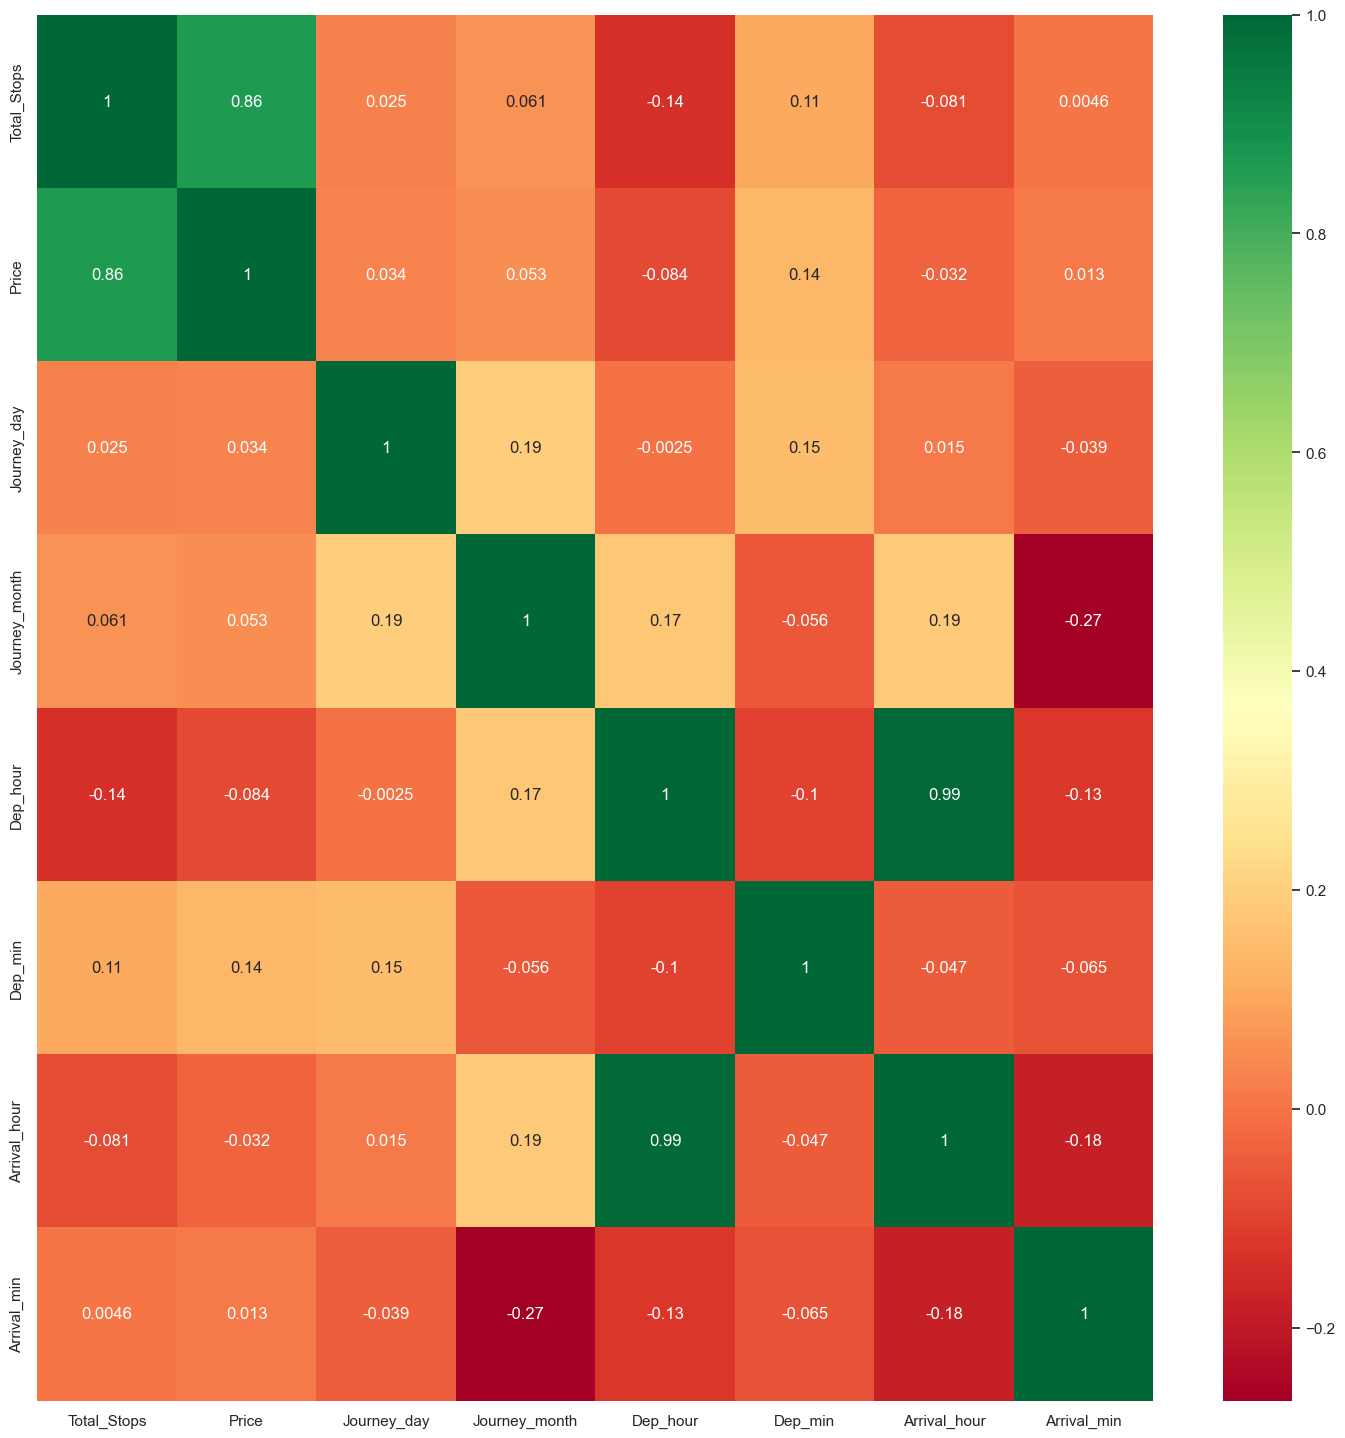

In [54]:
plt.figure(figsize = (18,18))
sns.heatmap(train_data.corr(), annot = True, cmap = "RdYlGn")

plt.show()

In [55]:
from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X, y)


ExtraTreesRegressor()

In [56]:
print(selection.feature_importances_)

[3.54566802e-01 6.43124606e-01 1.56217571e-04 3.41013338e-04
 1.77261030e-04 2.05319770e-04 1.53847622e-04 3.94157251e-04
 7.70969844e-04 6.17930872e-06 2.02925447e-05 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.19735266e-05
 0.00000000e+00 0.00000000e+00 5.12653760e-06 3.62344432e-05]


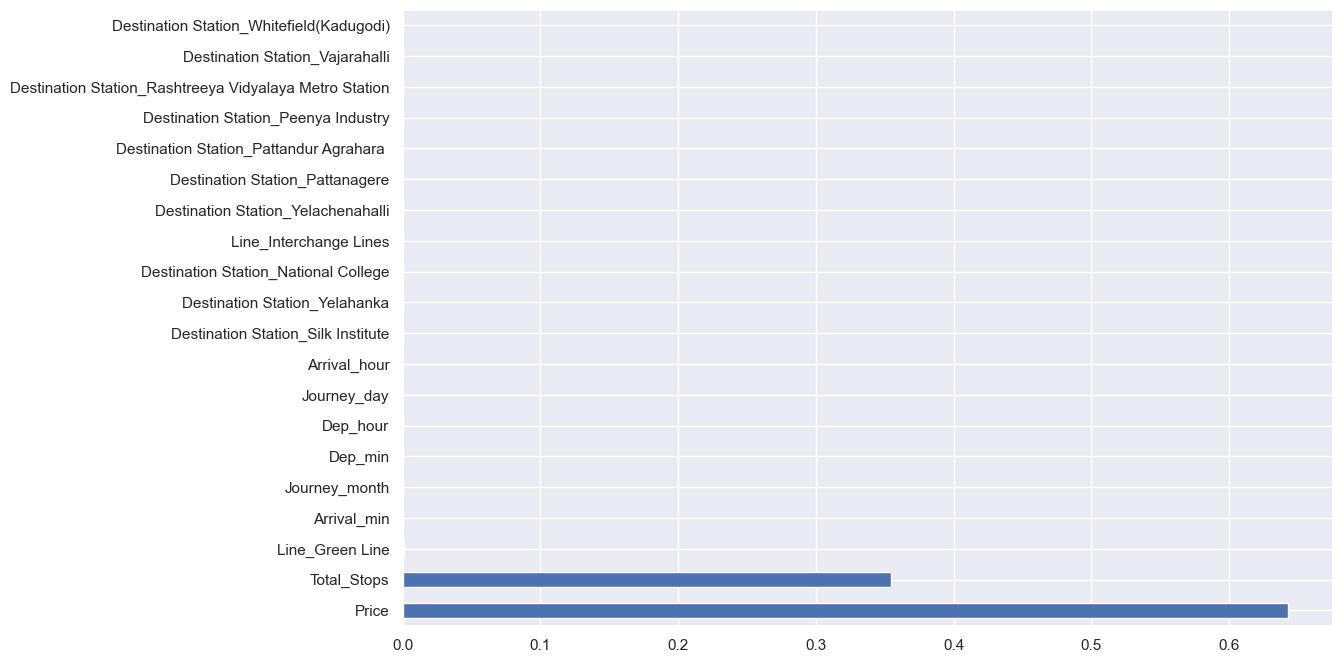

In [57]:
plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

# Fitting the model using Random Forest

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [59]:
from sklearn.ensemble import RandomForestRegressor
reg_rf = RandomForestRegressor()
reg_rf.fit(X_train, y_train)

RandomForestRegressor()

In [60]:
y_pred = reg_rf.predict(X_test)

In [61]:
reg_rf.score(X_train, y_train)

0.9987006339775198

In [62]:
reg_rf.score(X_test, y_test)

0.9748686363847692

C:\Users\ganes\AppData\Local\Temp\ipykernel_12556\3453123835.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred)


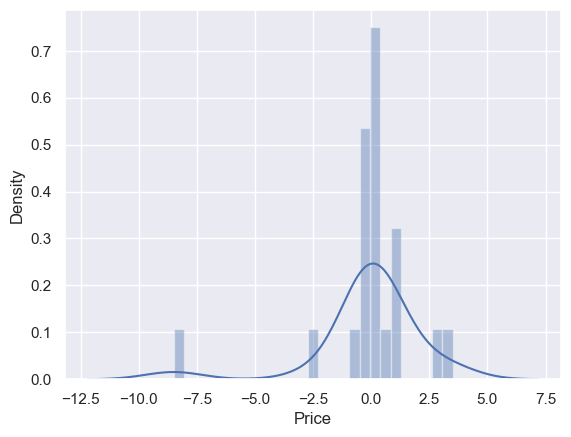

In [63]:
sns.distplot(y_test-y_pred)
plt.show()

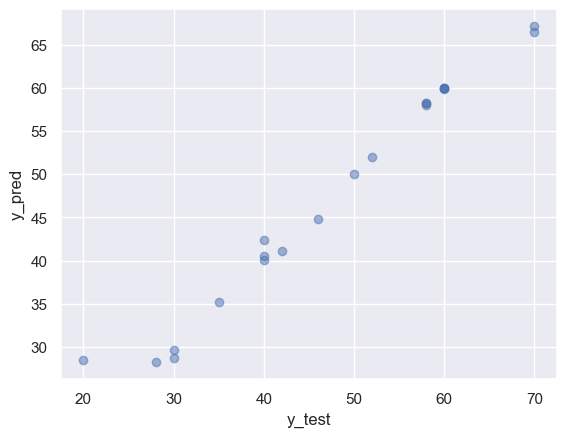

In [64]:
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

In [65]:
from sklearn import metrics

In [66]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 1.0904761904761902
MSE: 4.902952380952379
RMSE: 2.2142611365763476


In [67]:
2.245731400637557/(max(y)-min(y))

0.04491462801275114

In [68]:
metrics.r2_score(y_test, y_pred)

0.9748686363847692

In [69]:
# Assume X_train is your training DataFrame
feature_names = X_train.columns.tolist()


In [70]:
feature_names

['Total_Stops',
 'Price',
 'Journey_day',
 'Journey_month',
 'Dep_hour',
 'Dep_min',
 'Arrival_hour',
 'Arrival_min',
 'Line_Green Line',
 'Line_Interchange Lines',
 'Destination Station_National College',
 'Destination Station_Pattanagere',
 'Destination Station_Pattandur Agrahara ',
 'Destination Station_Peenya Industry',
 'Destination Station_Rashtreeya Vidyalaya Metro Station',
 'Destination Station_Silk Institute',
 'Destination Station_Vajarahalli',
 'Destination Station_Whitefield(Kadugodi)',
 'Destination Station_Yelachenahalli',
 'Destination Station_Yelahanka']

In [71]:
new_data = {
    'Total_Stops': [10, 12], 
    'Journey_day': [15, 20], 
    'Journey_month': [6, 7], 
    'Dep_hour': [10, 18], 
    'Dep_min': [15, 45], 
    'Arrival_hour': [12, 20], 
    'Arrival_min': [30, 55],   
    'Line_Green Line':[0,1],
    'Line_Interchange Lines' : [1, 1], 
    'Destination Station_National College':[0,0],
    'Destination Station_Pattanagere':[1,0],
    'Destination Station_Pattandur Agrahara':[1,1],
    'Destination Station_Peenya Industry':[0,0],
    'Destination Station_Rashtreeya Vidyalaya Metro Station':[0,0],
    'Destination Station_Silk Institute':[0,1],
    'Destination Station_Vajarahalli':[1,0],
    'Destination Station_Whitefield(Kadugodi)':[0,0],
    'Destination Station_Yelachenahalli':[1,1],
    'Destination Station_Yelahanka': [0, 0],  
    'Destination Station_Jayanagar': [0, 1], 
    'Destination Station_Jalahalli': [0, 0]
}

new_df = pd.DataFrame(new_data)
for col in feature_names:
    
    if col not in new_df.columns:
        new_df[col] = 0
        
new_df = new_df[feature_names]

predictions = reg_rf.predict(new_df)

print("Predicted fares for the new data:")
print(predictions)

Predicted fares for the new data:
[29.26 31.99]
